In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("/kaggle/input/datasets/shamiulislamshifat/handwritten-digits-recognition/DataB.csv")

df.head()

,Unnamed: 0,fea.1,fea.2,fea.3,fea.4,fea.5,fea.6,fea.7,fea.8,fea.9,...,fea.776,fea.777,fea.778,fea.779,fea.780,fea.781,fea.782,fea.783,fea.784,gnd
0,1,4,4,3,0,0,4,2,1,4,...,1,3,0,4,2,1,1,4,5,0
1,2,5,1,4,3,1,3,5,1,4,...,1,1,3,3,1,3,3,5,4,0
2,3,1,3,0,3,1,1,0,1,0,...,3,0,2,4,2,2,1,2,4,0
3,4,5,3,2,3,5,2,2,0,4,...,5,4,5,1,4,4,2,4,4,0
4,5,3,5,3,3,0,4,1,1,4,...,1,3,3,3,1,2,4,1,1,0


In [3]:
df.sample()

,Unnamed: 0,fea.1,fea.2,fea.3,fea.4,fea.5,fea.6,fea.7,fea.8,fea.9,...,fea.776,fea.777,fea.778,fea.779,fea.780,fea.781,fea.782,fea.783,fea.784,gnd
539,540,3,3,3,5,3,0,1,5,4,...,4,3,1,2,5,2,4,1,3,1


In [4]:
df.shape

(2066, 786)

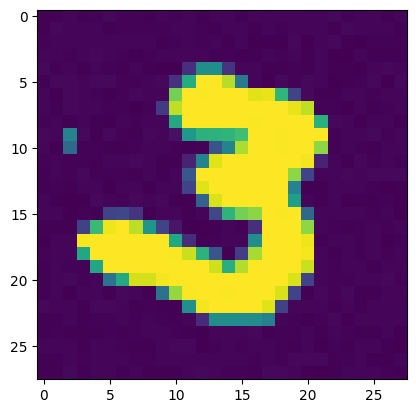

In [5]:
plt.imshow(df.iloc[1353, 1:-1].values.reshape(28, 28))

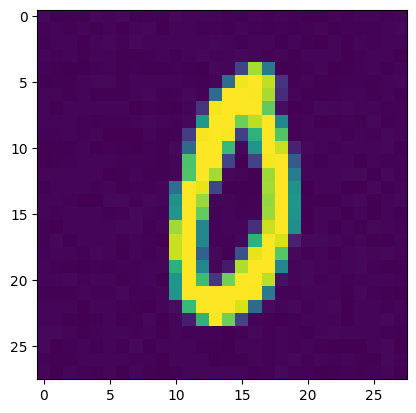

In [6]:
plt.imshow(df.iloc[250, 1:-1].values.reshape(28, 28))

In [27]:
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

print(f'shape of X: {X.shape}')
print(f'shape of y: {y.shape}')

shape of X: (2066, 784)
shape of y: (2066,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train.shape, X_test.shape

((1652, 784), (414, 784))

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [10]:
y_pred = knn.predict(X_test)

In [11]:
y_pred

array([3, 4, 2, 4, 0, 2, 4, 2, 1, 1, 3, 1, 1, 0, 2, 2, 0, 4, 0, 3, 0, 0,
       0, 1, 4, 2, 1, 2, 3, 0, 3, 1, 1, 4, 2, 3, 1, 3, 4, 0, 3, 3, 3, 4,
       0, 1, 0, 0, 3, 2, 2, 4, 3, 1, 1, 4, 2, 1, 1, 1, 2, 1, 1, 1, 0, 2,
       4, 3, 1, 2, 3, 4, 1, 0, 1, 4, 1, 3, 3, 4, 3, 4, 3, 0, 3, 0, 0, 0,
       0, 3, 4, 0, 2, 4, 3, 3, 3, 3, 2, 4, 4, 1, 2, 1, 1, 0, 4, 1, 3, 3,
       1, 4, 3, 1, 3, 1, 4, 2, 1, 2, 4, 0, 0, 1, 1, 2, 3, 4, 4, 0, 4, 3,
       3, 2, 1, 1, 3, 1, 2, 1, 3, 1, 1, 2, 0, 1, 4, 0, 0, 2, 2, 2, 0, 1,
       3, 3, 1, 3, 1, 1, 0, 2, 1, 0, 3, 1, 1, 2, 3, 1, 2, 3, 3, 3, 4, 0,
       2, 4, 2, 0, 1, 0, 1, 4, 4, 3, 1, 3, 1, 1, 0, 1, 2, 3, 2, 0, 0, 3,
       3, 3, 3, 1, 2, 0, 3, 2, 3, 0, 3, 1, 3, 3, 0, 0, 0, 1, 1, 3, 4, 2,
       0, 4, 4, 1, 2, 1, 4, 3, 3, 1, 4, 3, 3, 1, 3, 4, 3, 4, 4, 2, 3, 4,
       2, 0, 0, 1, 0, 2, 2, 0, 4, 1, 1, 1, 0, 0, 1, 3, 1, 2, 1, 0, 0, 3,
       4, 4, 1, 2, 2, 4, 0, 4, 1, 1, 4, 3, 2, 1, 2, 1, 4, 1, 4, 3, 4, 2,
       0, 1, 3, 3, 2, 4, 0, 3, 0, 2, 0, 1, 1, 1, 3,

In [12]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.9541062801932367


## Apply PCA

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# step-1: standardisatioin

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=None)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# calculating eigen values and eigen vectors
# sort and select the biggest eigen vector, that will be largest varience
# transform the data to lower dimensional space

In [15]:
X_train.shape, X_test.shape # because we used None in PCA

((1652, 784), (414, 784))

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# calculating eigen values and eigen vectors
# sort and select the biggest eigen vector, that will be largest varience
# transform the data to lower dimensional space

In [17]:
X_train.shape, X_test.shape # because we used 100 in n_components in PCA

((1652, 100), (414, 100))

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy_score(y_test, y_pred)

# with only 100 columns, from the PCA

0.9444444444444444

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=500)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# calculating eigen values and eigen vectors
# sort and select the biggest eigen vector, that will be largest varience
# transform the data to lower dimensional space

In [24]:
X_train.shape, X_test.shape # because we used 500 in n_components in PCA

((1652, 500), (414, 500))

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy_score(y_test, y_pred)

# with only 500 columns, from the PCA

0.9541062801932367

## Tring PCA from 1 to 784

In [ ]:
for i in range(1, 785):
    pca = PCA(n_components=i)

    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)

    knn = KNeighborsClassifier()
    knn.fit(X_train_trf, y_train)
    
    y_pred = knn.predict(X_test_trf)
    print(f"{i} --> {accuracy_score(y_test, y_pred)}")

1 --> 0.5169082125603864
2 --> 0.7608695652173914
3 --> 0.8333333333333334
4 --> 0.8671497584541062
5 --> 0.9202898550724637
6 --> 0.9444444444444444
7 --> 0.9516908212560387
8 --> 0.9637681159420289
9 --> 0.9565217391304348
10 --> 0.9710144927536232
11 --> 0.9637681159420289
12 --> 0.9685990338164251
13 --> 0.9637681159420289
14 --> 0.961352657004831
15 --> 0.9637681159420289
16 --> 0.9685990338164251
17 --> 0.9710144927536232
18 --> 0.9734299516908212
19 --> 0.9734299516908212
20 --> 0.9734299516908212
21 --> 0.9685990338164251
22 --> 0.966183574879227
23 --> 0.9685990338164251
24 --> 0.9685990338164251
25 --> 0.966183574879227
26 --> 0.9637681159420289
27 --> 0.966183574879227
28 --> 0.966183574879227
29 --> 0.9685990338164251
30 --> 0.9685990338164251
31 --> 0.9685990338164251
32 --> 0.9685990338164251
33 --> 0.966183574879227
34 --> 0.9685990338164251
35 --> 0.966183574879227
36 --> 0.9710144927536232
37 --> 0.9685990338164251
38 --> 0.9685990338164251
39 --> 0.9685990338164251
40